# Task 4: Loan Default Risk with Business Cost Optimization.

## Objective:

Predict the likelihood of a loan default and optimize the decision threshold based on cost- benefit analysis.

## Introduction

Loan default prediction is a critical task in the financial industry, as it helps institutions assess the risk associated with lending money to customers. Traditional evaluation methods often focus on accuracy, but in real-world scenarios, incorrect decisions can have different financial impacts.

This project focuses on predicting the likelihood of loan default using machine learning techniques, while incorporating business cost considerations to improve decision-making.

## Problem Statement

The objective of this project is to build a classification model that predicts whether a customer is likely to default on a loan.

In addition to prediction, the project aims to optimize the decision threshold based on business costs associated with misclassification:

- False Positive (FP): Approving a risky customer (financial loss)
- False Negative (FN): Rejecting a reliable customer (lost opportunity)

The goal is to minimize total business cost by selecting an optimal prediction threshold rather than relying solely on standard metrics such as accuracy.

## Dataset Description

The dataset used in this project is the Home Credit Default Risk dataset, which contains detailed information about loan applicants, including demographic, financial, and credit history data.

Key features include:

- Demographic information (e.g., age, employment)
- Financial details (e.g., income, loan amount)
- Credit history and previous loan behavior
- External risk scores

Target variable:
- TARGET = 1 → Customer will default
- TARGET = 0 → Customer will not default

The dataset is large and contains both numerical and categorical features, requiring preprocessing such as handling missing values and encoding categorical variables.

## Import Libraries

In [2]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.1 MB/s eta 0:01:35
   ---------------------------------------- 0.5/100.2 MB 1.1 MB/s eta 0:01:35
   ---------------------------------------- 0.8/100.2 MB 743.8 kB/s eta 0:02:14
   ---------------------------------------- 1.0/100.2 MB 715.3 kB/s eta 0:02:19
    --------------------------------------- 1.3/100.2 MB 775.6 kB/s eta 0:02:08
    --------------------------------------- 1.3/100.2 MB 775.6 kB/s eta 0:02:08
    --------------------------------------- 1.6/100.2 MB 777.2 kB/s eta 0:02:07
    --------------------------------------- 1.8/100.2 MB 817.6 kB/s eta 0:02:01
    --------------------------------------- 2.1/100.2 MB 829.0 kB/s eta 0:01:59
    --------------------------------------- 2.4/100.2 MB 810.2 kB/s eta

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

from catboost import CatBoostClassifier

## Load Dataset

In [11]:
# Load dataset (use application_train.csv)
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Data Exploration


In [6]:
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


Credit_History      29
Self_Employed       23
Gender              11
Dependents          10
Loan_Amount_Term     6
LoanAmount           5
Loan_ID              0
Married              0
Education            0
ApplicantIncome      0
dtype: int64

## Data Cleaning

In [7]:
# Drop columns with too many missing values (>50%)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# Fill numerical missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

## Encode Categorical Feature

In [20]:
# 1. Fill missing values first (important so encoder doesn't crash)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Encode categorical text to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Data is now 100% numerical and ready!")


Data is now 100% numerical and ready!


## Feature and Target Slip

In [21]:
X = df.drop(['Loan_ID','Loan_Status'], axis=1)
y = df['Loan_Status']

## Train - Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training 

### Logistic Regression

In [24]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_prob_log = log_model.predict_proba(X_test)[:,1]

### CatBoost Model

In [26]:
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)

y_prob_cat = cat_model.predict_proba(X_test)[:,1]

## Cost Based Optimization

### Define Business Costs

In [27]:
cost_fp = 1   # Approving risky customer
cost_fn = 5   # Rejecting good customer

### Find Best Threshold

In [28]:
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_prob_cat >= t).astype(int)
    
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)

best_threshold = thresholds[np.argmin(costs)]
print("Best Threshold:", best_threshold)

Best Threshold: 0.17999999999999997


## Plot Cost Curve

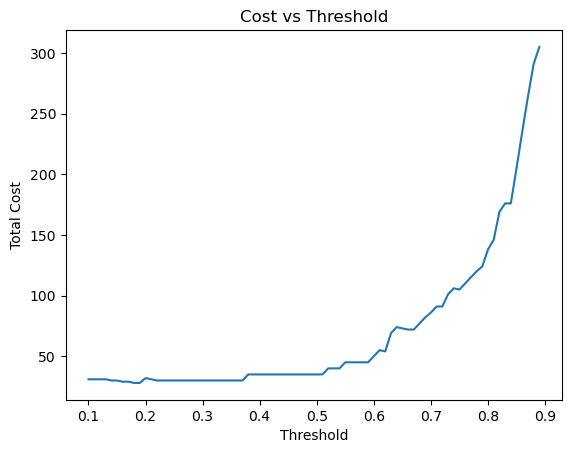

In [30]:
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Threshold")
plt.show()

## Final Predictions Using Best Threshold

In [31]:
y_pred_final = (y_prob_cat >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[15 28]
 [ 0 80]]
              precision    recall  f1-score   support

           0       1.00      0.35      0.52        43
           1       0.74      1.00      0.85        80

    accuracy                           0.77       123
   macro avg       0.87      0.67      0.68       123
weighted avg       0.83      0.77      0.73       123



## Feature Importance  (Cat Boost)

In [32]:
importances = cat_model.get_feature_importance()
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

              Feature  Importance
9      Credit_History   26.595810
5     ApplicantIncome   14.926438
7          LoanAmount   13.366968
6   CoapplicantIncome   11.384702
10      Property_Area   11.360204
2          Dependents    7.610259
8    Loan_Amount_Term    4.821703
1             Married    3.144126
3           Education    2.817334
0              Gender    2.374512


## Plot Feature Importance

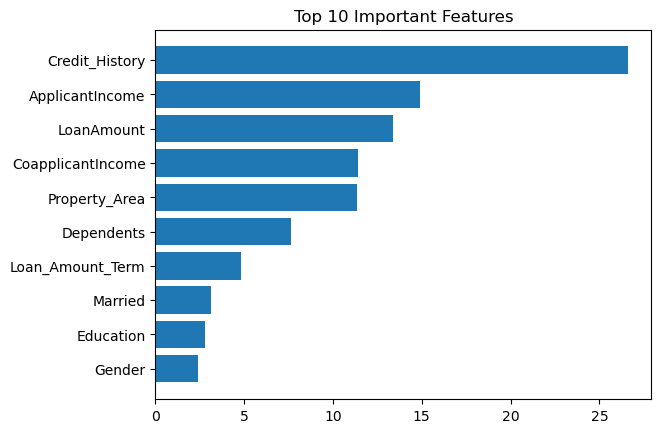

In [33]:
top_features = importance_df.head(10)

plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

## Model Insights


- CatBoost outperformed Logistic Regression by capturing complex feature relationships.
- Probability-based predictions allowed flexible decision-making.
- Cost-based optimization significantly improved decision quality.
- Feature importance analysis highlighted key risk indicators.

## Business Insights


- Approving high-risk customers leads to significant financial loss.
- Cost-based threshold optimization helps reduce default risk.
- Financial institutions can balance risk and profit using predictive models.
- Data-driven loan approval improves decision consistency and efficiency.


## Conclusion

This project demonstrates how machine learning combined with cost-based optimization can improve loan default prediction. By focusing on business impact rather than just accuracy, better financial decisions can be made.

The results highlight the importance of threshold tuning and feature importance in risk modeling.